In [16]:
# procrustes with precomputed CLIP embeddings, with retrieval and gap metrics

import sys
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader    
sys.path.append(os.path.abspath(".."))
from analysis.viz import visualize_3d, tsne_3d
from analysis.modality_gap import compute_gap
from metrics.retrieval import retrieval

import procrustes
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, random_split

import torch.nn.functional as F

# Add parent directory to Python path so we can import `models.*`
seed = 123
g = torch.Generator().manual_seed(seed)


In [13]:
class EmbeddingsDataset(Dataset):
    def __init__(self, precomputed_dir, split_name="flickr30k"):
        """
        Args:
            precomputed_dir (str): Directory where the precomputed .npz files are stored.
            split_name (str): Name of the dataset split (e.g., "flickr30k") to filter the files.
        """
        self.text_embeddings = []
        self.vision_embeddings = []
        
        # Load all .npz files that match the split_name
        for fn in os.listdir(precomputed_dir):
            if fn.endswith(".npz") and split_name in fn:
                data = np.load(os.path.join(precomputed_dir, fn))
                self.vision_embeddings.append(data["vision_emb"])
                self.text_embeddings.append(data["text_emb"])
        
        # Concatenate all loaded embeddings into single arrays
        self.text_embeddings = np.concatenate(self.text_embeddings, axis=0)  # [N, D]
        self.vision_embeddings = np.concatenate(self.vision_embeddings, axis=0)  # [N, D]

    def __len__(self):
        return len(self.text_embeddings)

    def __getitem__(self, idx):
        # random_idx = np.random.randint(0, len(self.text_embeddings[idx]))
        text_emb = torch.as_tensor(self.text_embeddings[idx][0]).float()
        vision_emb = torch.as_tensor(self.vision_embeddings[idx]).float()
        return text_emb, vision_emb


In [14]:
# def get_embeddings_dataloaders(precomputed_dir, split_name="flickr30k", batch_size=32, shuffle=True):
precomputed_dir = "/mnt/media/emanuele/few_dimensions/dataset/precomputed_embeddings/clip_vit_b_32___laion2b_s34b_b79k"
dataset = EmbeddingsDataset(precomputed_dir=precomputed_dir, split_name="flickr30k")
# split dataset into train/val/test non overlapping subsets
# train_size = int(0.8 * len(dataset))
train_size = 10000 
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size, test_size], generator=g
)
train_loader = DataLoader(train_dataset, batch_size=train_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

### Check for modality gap (pca and tsne)

In [4]:
train_iter = iter(train_loader)
text_emb, vision_emb = next(train_iter)
print("Text embedding shape:", text_emb.shape)  # Should be [batch_size, D]
print("Vision embedding shape:", vision_emb.shape)  # Should be [batch_size, D

Text embedding shape: torch.Size([10000, 512])
Vision embedding shape: torch.Size([10000, 512])


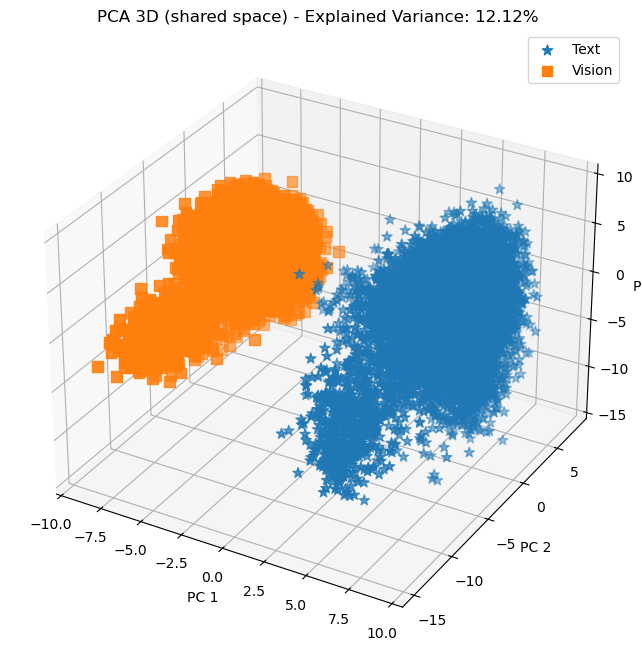

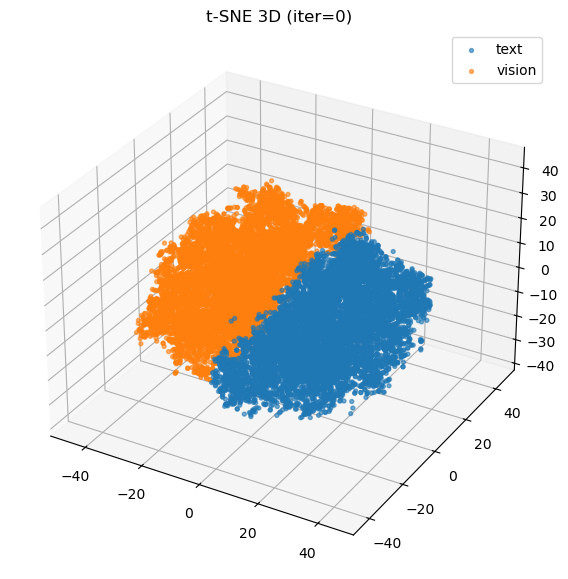

(array([[ 25.497347  , -19.17051   ,   3.7653964 ],
        [ 19.71704   ,  -7.7219625 , -20.193424  ],
        [  1.256957  ,   5.8411484 ,  -5.8121796 ],
        ...,
        [-29.736872  ,  16.672117  ,  12.820436  ],
        [-14.776919  ,  36.15816   ,   0.24911658],
        [  0.23788607,  24.142588  ,  10.4012375 ]], dtype=float32),
 array([0, 0, 0, ..., 1, 1, 1]))

In [5]:
visualize_3d(None, text_emb.numpy(), vision_emb.numpy(), iterations=0, save=False)
tsne_3d(None, text_emb.numpy(), vision_emb.numpy(), iterations=0)

### Diagnostic of the regime
- Are the embeddings already isometric between modalities?

In [5]:
def make_loaders(precomputed_dir, split_name="flickr30k", batch_size=256, seed=0, num_workers=0):
    ds = EmbeddingsDataset(precomputed_dir, split_name=split_name)
    n = len(ds)
    n_train = int(0.8 * n)
    n_test = n - n_train

    g = torch.Generator().manual_seed(seed)
    train_ds, test_ds = random_split(ds, [n_train, n_test], generator=g)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_loader, test_loader

In [6]:
def collect_embeddings(loader, max_samples=5000, device="cpu"):
    """
    Collects (text, vision) pairs from loader into numpy arrays.
    Each batch is (text_emb, vision_emb).
    """
    Xs, Ys = [], []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b in tqdm(loader, desc=f"Collecting {max_samples} samples"):
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b  = F.normalize(vis_b.to(device), dim=-1).cpu().numpy()
            Xs.append(text_b); Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break
    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]
    return X, Y

def procrustes_T(X, Y, translate=True, scale=True):
    res = procrustes.generic(X, Y, translate=translate, scale=scale)
    T = res.t
    err = float(res.error) if not hasattr(res.error, "item") else float(res.error.item())
    return T, err

def isometry_checks(X, Y, T=None, k=10):
    """
    Checks if geometry is similar: correlation of intra-modality distances + kNN overlap.
    Uses cosine distance (since normalized).
    """
    X_use = X @ T if T is not None else X

    DX = cdist(X_use, X_use, metric="cosine")
    DY = cdist(Y,     Y,     metric="cosine")

    iu = np.triu_indices(DX.shape[0], k=1)
    corr = spearmanr(DX[iu], DY[iu]).correlation

    knn_X = np.argsort(DX, axis=1)[:, 1:k+1]
    knn_Y = np.argsort(DY, axis=1)[:, 1:k+1]
    overlaps = [len(set(knn_X[i]).intersection(set(knn_Y[i]))) / k for i in range(DX.shape[0])]

    return float(corr), float(np.mean(overlaps))

In [9]:
def regime_diagnostics(train_loader, n_pool=5000, n_trials=10, subset_small=100, subset_large=2000,
                       translate=True, scale=True, seed=0, device="cpu"):
    rng = np.random.default_rng(seed)
    X_pool, Y_pool = collect_embeddings(train_loader, max_samples=n_pool, device=device)

    # visualize on a subset
    tsne_3d(None, X_pool[:1000], Y_pool[:1000], iterations="train_pool")

    def run_trials(m):
        Ts, errs, corrs_b, corrs_a, ov_b, ov_a = [], [], [], [], [], []
        for _ in range(n_trials):
            idx = rng.choice(X_pool.shape[0], size=m, replace=False)
            Xs, Ys = X_pool[idx], Y_pool[idx]

            T, err = procrustes_T(Xs, Ys, translate=translate, scale=scale)
            Ts.append(T); errs.append(err)

            c0, o0 = isometry_checks(Xs, Ys, T=None, k=10)
            c1, o1 = isometry_checks(Xs, Ys, T=T,   k=10)
            corrs_b.append(c0); ov_b.append(o0)
            corrs_a.append(c1); ov_a.append(o1)

        # stability of T across trials
        dists = []
        for i in range(len(Ts)):
            for j in range(i+1, len(Ts)):
                dists.append(np.linalg.norm(Ts[i] - Ts[j], ord="fro"))
        return {
            "mean_T_fro_dist": float(np.mean(dists)) if dists else 0.0,
            "mean_procrustes_err": float(np.mean(errs)),
            "isom_corr_before": float(np.mean(corrs_b)),
            "isom_corr_after": float(np.mean(corrs_a)),
            "knn_overlap_before": float(np.mean(ov_b)),
            "knn_overlap_after": float(np.mean(ov_a)),
        }

    small = run_trials(subset_small)
    large = run_trials(subset_large)

    print("\n=== REGIME DIAGNOSTICS ===")
    print(f"[SMALL m={subset_small}]")
    for k,v in small.items(): print(f"  {k}: {v:.4f}")
    print(f"\n[LARGE m={subset_large}]")
    for k,v in large.items(): print(f"  {k}: {v:.4f}")

    return small, large

#### ANALISI:
- mean_T_fro_dist
È la distanza media (Frobenius) tra le matrici T ottenute in trial diversi (subset diversi). Intuitivamente: bassa → la trasformazione stimata è stabile (stessa “mappa” anche cambiando i campioni), alta → la trasformazione è instabile (dipende da quali esempi hai pescato)
Questa è la metrica più diretta per capire se esiste un global mapping consistente.

- mean_procrustes_err
È l’errore restituito da procrustes.generic sul subset: quanto “bene” T riesce ad allineare quel subset secondo l’obiettivo Procrustes (tipicamente un errore Frobenius normalizzato):
basso → facile allineare in quel subset,
alto → alignment difficile (o geometrie diverse)

- isom_corr_before
Calcolo del coefficiente di Spearman intramodale: costruzione della matrice di similarità del coseno per text-text e vision-vision e poi calcolo della somiglianza: alta somiglianza ==> geometria simile.

- isom_corr_after
Stesso test, ma dopo aver trasformato il testo con 
T: confronti distanze di 𝑋𝑇 con distanze di 𝑌.
se sale molto, la trasformazione rende le geometrie più simili → buon segno per un mapping rigido.

- knn_overlap_before
Per ogni punto 𝑖 prendi i suoi k-nearest neighbors nello spazio testo e nello spazio visione e calcola l’overlap. Poi fai la media su 𝑖.
alto → i vicinati locali sono simili tra modalità (struttura locale compatibile)
basso → vicinati diversi

- knn_overlap_after
Uguale, ma usando 𝑋𝑇 al posto di 𝑋. Se aumenta, 𝑇 sta rendendo più simili i vicinati tra modalità.

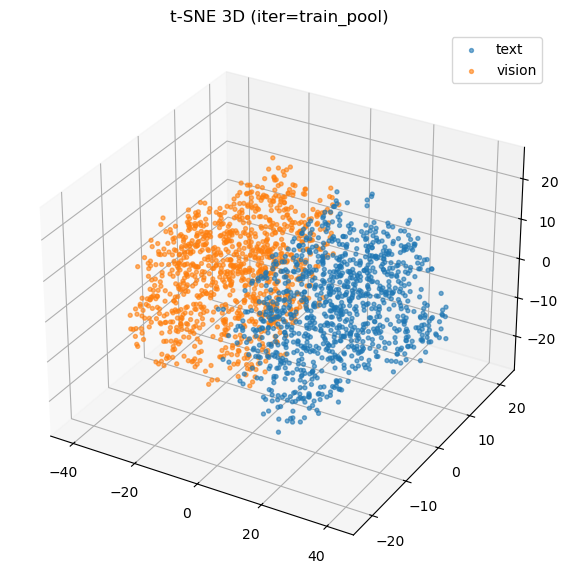


=== REGIME DIAGNOSTICS ===
[SMALL m=100]
  mean_T_fro_dist: 19.4794
  mean_procrustes_err: 0.0000
  isom_corr_before: 0.3281
  isom_corr_after: 0.7991
  knn_overlap_before: 0.3048
  knn_overlap_after: 0.7675

[LARGE m=2000]
  mean_T_fro_dist: 38.8199
  mean_procrustes_err: 0.5102
  isom_corr_before: 0.3127
  isom_corr_after: 0.5226
  knn_overlap_before: 0.1487
  knn_overlap_after: 0.2670


In [10]:
train_loader, test_loader = make_loaders(precomputed_dir, split_name="flickr30k", batch_size=256, seed=0, num_workers=0)

small_stats, large_stats = regime_diagnostics(
    train_loader,
    n_pool=5000,
    n_trials=10,
    subset_small=100,
    subset_large=2000,
    translate=True,
    scale=True,
    seed=0,
    device="cpu"
)

This results shows us (as expected) that the procrustes is sensitive to data sampling. The higher the "batch" the higher is the error and the lower is the ability of transformation matrix to induce similar geometry between data modalities.

Questi numeri suggeriscono:
- Procrustes su pochi campioni: può dare impressione di “quasi isometria” ma è probabilmente un fit locale / overfit.
- Procrustes su tanti campioni: rivela che la relazione non è una sola trasformazione globale; c’è eterogeneità (semantica o strutturale).

### Fit a more general procrustes


In [7]:
def fit_procrustes_on_10k(train_loader, n_fit=10_000, translate=True, scale=True, device="cpu"):
    X_fit, Y_fit = collect_embeddings(train_loader, max_samples=n_fit, device=device)
    res = procrustes.generic(X_fit, Y_fit, translate=translate, scale=scale)
    T = res.t
    fit_err = float(res.error) if not hasattr(res.error, "item") else float(res.error.item())

    # store preprocessing stats consistent with translate/scale (standard)
    mu_X = X_fit.mean(axis=0, keepdims=True)
    mu_Y = Y_fit.mean(axis=0, keepdims=True)
    eps = 1e-12
    s_X = np.linalg.norm(X_fit - mu_X, ord="fro") + eps
    s_Y = np.linalg.norm(Y_fit - mu_Y, ord="fro") + eps

    return {"T": T, "mu_X": mu_X, "mu_Y": mu_Y, "s_X": s_X, "s_Y": s_Y, "fit_error": fit_err}

In [8]:
def apply_mapping_np(X, Y, mapping, renorm=True):
    eps = 1e-12
    Xp = (X - mapping["mu_X"]) / mapping["s_X"]
    Yp = (Y - mapping["mu_Y"]) / mapping["s_Y"]
    X_al = Xp @ mapping["T"]
    Y_al = Yp
    if renorm:
        X_al = X_al / (np.linalg.norm(X_al, axis=1, keepdims=True) + eps)
        Y_al = Y_al / (np.linalg.norm(Y_al, axis=1, keepdims=True) + eps)
    return X_al, Y_al

def eval_test_pre_post( test_loader, mapping, gaps=('RMG','L2M','L2I'), device="cpu"):
    r_orig = {1: [], 5: [], 10: []}
    r_al   = {1: [], 5: [], 10: []}

    X_all, Y_all = [], []
    Xal_all, Yal_all = [], []

    with torch.no_grad():
        for text_b, vis_b in tqdm(test_loader, desc="Eval test pre/post"):
            X = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            Y = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()

            r_orig[1].append(retrieval(X, Y, top_k=1))
            r_orig[5].append(retrieval(X, Y, top_k=5))
            r_orig[10].append(retrieval(X, Y, top_k=10))

            X_al, Y_al = apply_mapping_np(X, Y, mapping, renorm=True)
            r_al[1].append(retrieval(X_al, Y_al, top_k=1))
            r_al[5].append(retrieval(X_al, Y_al, top_k=5))
            r_al[10].append(retrieval(X_al, Y_al, top_k=10))

            X_all.append(X); Y_all.append(Y)
            Xal_all.append(X_al); Yal_all.append(Y_al)

    X_all = np.concatenate(X_all, axis=0)
    Y_all = np.concatenate(Y_all, axis=0)
    Xal_all = np.concatenate(Xal_all, axis=0)
    Yal_all = np.concatenate(Yal_all, axis=0)

    gaps_orig, gaps_al = {}, {}
    for g in gaps:
        go = compute_gap( g, X_all, Y_all, iterations=None)
        ga = compute_gap( g, Xal_all, Yal_all, iterations=None)
        gaps_orig[g] = go["text_vision"] if isinstance(go, dict) and "text_vision" in go else go
        gaps_al[g]   = ga["text_vision"] if isinstance(ga, dict) and "text_vision" in ga else ga

    print("\n=== TEST RESULTS ===")
    print(f"Procrustes fit_error on 10k: {mapping['fit_error']:.6f}")
    print(f"Retrieval@1  orig: {np.mean(r_orig[1]):.4f} | aligned: {np.mean(r_al[1]):.4f}")
    print(f"Retrieval@5  orig: {np.mean(r_orig[5]):.4f} | aligned: {np.mean(r_al[5]):.4f}")
    print(f"Retrieval@10 orig: {np.mean(r_orig[10]):.4f} | aligned: {np.mean(r_al[10]):.4f}")
    print("Gaps original:", gaps_orig)
    print("Gaps aligned :", gaps_al)

    # t-SNE quick look
    tsne_3d(X_all[:1000], Y_all[:1000], iterations="test_orig")
    tsne_3d(Xal_all[:1000], Yal_all[:1000], iterations="test_aligned")

    return {
        "retrieval_orig": {k: float(np.mean(v)) for k,v in r_orig.items()},
        "retrieval_aligned": {k: float(np.mean(v)) for k,v in r_al.items()},
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_al
    }

Eval test pre/post: 100%|██████████| 25/25 [00:00<00:00, 217.55it/s]



=== TEST RESULTS ===
Procrustes fit_error on 10k: 0.648491
Retrieval@1  orig: 0.8746 | aligned: 0.7309
Retrieval@5  orig: 0.9742 | aligned: 0.9254
Retrieval@10 orig: 0.9877 | aligned: 0.9647
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924092292786, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.6547232304881285, 'L2M': 0.026744429022073746, 'L2I': 0.9641363024711609}


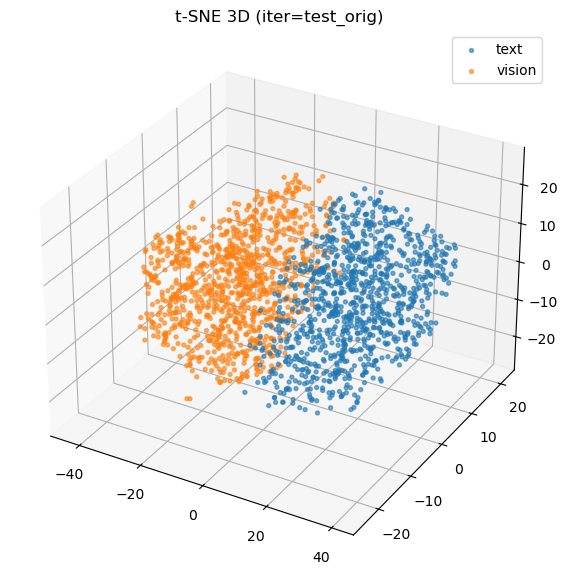

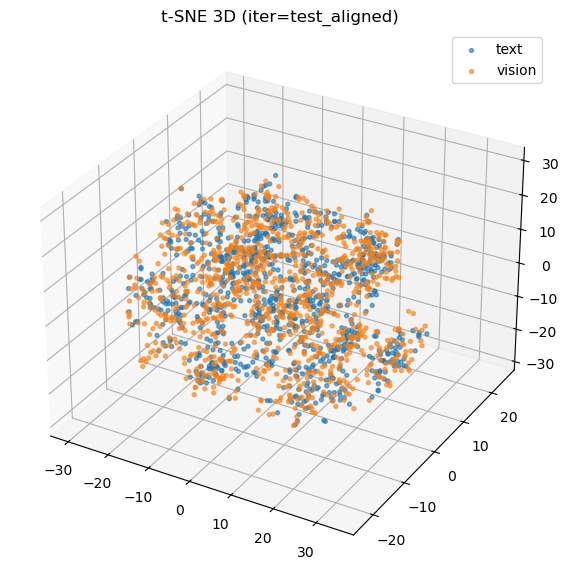

In [16]:
train_loader, test_loader = make_loaders(precomputed_dir, split_name="flickr30k", batch_size=256, seed=0, num_workers=0)

mapping_10k = fit_procrustes_on_10k(train_loader, n_fit=10_000, translate=True, scale=True, device="cpu")
test_stats = eval_test_pre_post(test_loader, mapping_10k, device="cpu")

In [20]:
# Export the mappping for potential reuse
import json
mapping_to_save = {
    "T": mapping_10k["T"].tolist(),  # Convert numpy array to list for JSON serialization
    "mu_X": mapping_10k["mu_X"].tolist(),
    "mu_Y": mapping_10k["mu_Y"].tolist(),
    "s_X": mapping_10k["s_X"].tolist(),
    "s_Y": mapping_10k["s_Y"].tolist(),
    "fit_error": mapping_10k["fit_error"]
}
with open("procrustes_mapping_10k.json", "w") as f:
    json.dump(mapping_to_save, f)   
    
    

### Subspace alignment

In [23]:
def fit_subspace_alignment(train_loader, n_fit=10_000, d_sub=256, device="cpu"):
    X, Y = collect_embeddings(train_loader, max_samples=n_fit, device=device)  # X=text, Y=vision

    # center (PCA-style)
    muX = X.mean(axis=0, keepdims=True)
    muY = Y.mean(axis=0, keepdims=True)
    Xc = X - muX
    Yc = Y - muY

    # SVD to get bases Ws, Wt (top d_sub right singular vectors)
    # Xc = U S V^T => Ws = V[:, :d_sub]
    _, _, VtX = np.linalg.svd(Xc, full_matrices=False)
    _, _, VtY = np.linalg.svd(Yc, full_matrices=False)

    Ws = VtX[:d_sub].T   # (D, d_sub)
    Wt = VtY[:d_sub].T   # (D, d_sub)

    # closed-form subspace alignment
    Phi = Wt.T @ Ws      # (d_sub, d_sub)   Eq (7) in the paper :contentReference[oaicite:4]{index=4}

    return {"muX": muX, "muY": muY, "Ws": Ws, "Wt": Wt, "Phi": Phi, "d_sub": d_sub}

In [24]:
def apply_subspace_alignment(X, Y, model, renorm=True):
    eps = 1e-12
    muX, muY = model["muX"], model["muY"]
    Ws, Wt, Phi = model["Ws"], model["Wt"], model["Phi"]

    # center
    Xc = X - muX
    Yc = Y - muY

    # align Y into X-space (Eq. 10 style) :contentReference[oaicite:6]{index=6}
    Y_al = Yc @ Wt @ Phi @ Ws.T

    # optionally bring back to X mean
    Y_al = Y_al + muX

    if renorm:
        Xn = X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)
        Yn = Y / (np.linalg.norm(Y, axis=1, keepdims=True) + eps)
        Yaln = Y_al / (np.linalg.norm(Y_al, axis=1, keepdims=True) + eps)
        return Xn, Yn, Yaln
    return X, Y, Y_al


def eval_subspace_alignment(test_loader, model, device="cpu", gaps=("RMG","L2M","L2I")):
    r_orig = {1: [], 5: [], 10: []}
    r_al   = {1: [], 5: [], 10: []}

    X_all, Y_all, Yal_all = [], [], []

    with torch.no_grad():
        for text_b, vis_b in tqdm(test_loader, desc="Eval subspace alignment"):
            X = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            Y = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()

            # original retrieval
            r_orig[1].append(retrieval(X, Y, top_k=1))
            r_orig[5].append(retrieval(X, Y, top_k=5))
            r_orig[10].append(retrieval(X, Y, top_k=10))

            # aligned vision -> text-space
            Xn, Yn, Yaln = apply_subspace_alignment(X, Y, model, renorm=True)

            r_al[1].append(retrieval(Xn, Yaln, top_k=1))
            r_al[5].append(retrieval(Xn, Yaln, top_k=5))
            r_al[10].append(retrieval(Xn, Yaln, top_k=10))

            X_all.append(Xn); Y_all.append(Yn); Yal_all.append(Yaln)

    X_all = np.concatenate(X_all, axis=0)
    Y_all = np.concatenate(Y_all, axis=0)
    Yal_all = np.concatenate(Yal_all, axis=0)

    gaps_orig, gaps_al = {}, {}
    for g in gaps:
        go = compute_gap(g, X_all, Y_all, iterations=None)
        ga = compute_gap(g, X_all, Yal_all, iterations=None)
        gaps_orig[g] = go["text_vision"] if isinstance(go, dict) and "text_vision" in go else go
        gaps_al[g]   = ga["text_vision"] if isinstance(ga, dict) and "text_vision" in ga else ga

    print("\n=== SUBSPACE ALIGNMENT TEST RESULTS ===")
    print(f"d_sub = {model['d_sub']}")
    print(f"Retrieval@1  orig: {np.mean(r_orig[1]):.4f} | aligned: {np.mean(r_al[1]):.4f}")
    print(f"Retrieval@5  orig: {np.mean(r_orig[5]):.4f} | aligned: {np.mean(r_al[5]):.4f}")
    print(f"Retrieval@10 orig: {np.mean(r_orig[10]):.4f} | aligned: {np.mean(r_al[10]):.4f}")
    print("Gaps original:", gaps_orig)
    print("Gaps aligned :", gaps_al)

    return {
        "retrieval_orig": {k: float(np.mean(v)) for k,v in r_orig.items()},
        "retrieval_aligned": {k: float(np.mean(v)) for k,v in r_al.items()},
        "gaps_orig": gaps_orig,
        "gaps_aligned": gaps_al
    }

In [28]:
# opzionale: prova diversi d_sub
for d in [32, 64, 128, 256, 384]:
    sub_model = fit_subspace_alignment(train_loader, n_fit=10_000, d_sub=d, device="cpu")
    _ = eval_subspace_alignment(test_loader, sub_model, device="cpu")

Eval subspace alignment: 100%|██████████| 25/25 [00:00<00:00, 220.56it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 32
Retrieval@1  orig: 0.8746 | aligned: 0.5406
Retrieval@5  orig: 0.9742 | aligned: 0.8407
Retrieval@10 orig: 0.9877 | aligned: 0.9180
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924688339233, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.7418968617387169, 'L2M': 0.3014943301677704, 'L2I': 0.8425172567367554}


Eval subspace alignment: 100%|██████████| 25/25 [00:00<00:00, 218.00it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 64
Retrieval@1  orig: 0.8746 | aligned: 0.7365
Retrieval@5  orig: 0.9742 | aligned: 0.9356
Retrieval@10 orig: 0.9877 | aligned: 0.9671
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924688339233, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.7147150678988811, 'L2M': 0.23713606595993042, 'L2I': 0.8264103531837463}


Eval subspace alignment: 100%|██████████| 25/25 [00:00<00:00, 214.34it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 128
Retrieval@1  orig: 0.8746 | aligned: 0.8362
Retrieval@5  orig: 0.9742 | aligned: 0.9629
Retrieval@10 orig: 0.9877 | aligned: 0.9834
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924688339233, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.6988464308853876, 'L2M': 0.16616225242614746, 'L2I': 0.8330492377281189}


Eval subspace alignment: 100%|██████████| 25/25 [00:00<00:00, 203.35it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 256
Retrieval@1  orig: 0.8746 | aligned: 0.8586
Retrieval@5  orig: 0.9742 | aligned: 0.9715
Retrieval@10 orig: 0.9877 | aligned: 0.9849
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924688339233, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.7022089214672783, 'L2M': 0.0890965685248375, 'L2I': 0.8763177394866943}


Eval subspace alignment: 100%|██████████| 25/25 [00:00<00:00, 210.29it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 384
Retrieval@1  orig: 0.8746 | aligned: 0.8622
Retrieval@5  orig: 0.9742 | aligned: 0.9715
Retrieval@10 orig: 0.9877 | aligned: 0.9862
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924688339233, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.7102776515662346, 'L2M': 0.05012039095163345, 'L2I': 0.9108297228813171}


Dimensione 256 ==> con subspace alignment posso ridurre il gap senza distruggere la performance

L’allineamento globale (Procrustes) riduce fortemente le distanze medie tra modalità (L2M, L2I) ma degrada le relazioni locali responsabili del retrieval. Subspace alignment, invece, agisce come un filtro: proiettando su un sottospazio principale e riallineando le basi, riduce il gap mantenendo quasi invariata la performance per  𝑑sub sufficientemente grande (≈256). Questo suggerisce che la discrepanza tra modalità è concentrata in componenti specifiche dello spazio, mentre un sottospazio semantico condiviso esiste e può essere allineato.

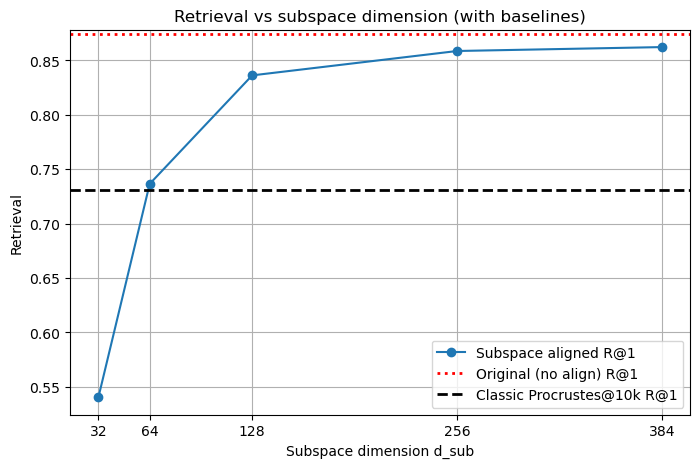

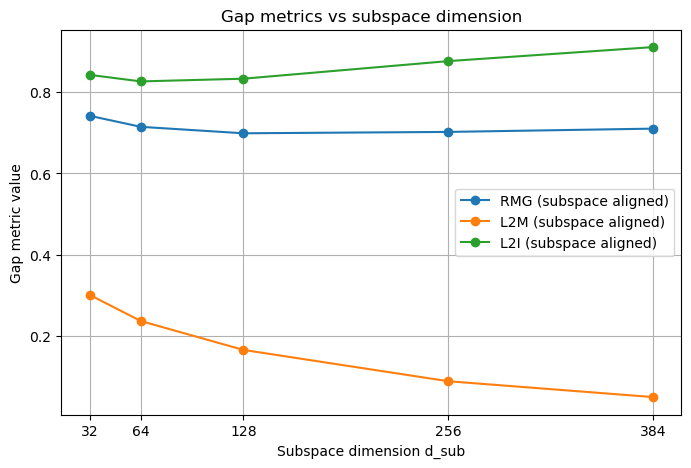

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Subspace sweep results (aligned) ---
results = [
    {"d_sub": 32,  "retrieval@1": 0.5406, "retrieval@5": 0.8407, "retrieval@10": 0.9180,
     "RMG": 0.7418968617387169, "L2M": 0.3014943301677704, "L2I": 0.8425172567367554},
    {"d_sub": 64,  "retrieval@1": 0.7365, "retrieval@5": 0.9356, "retrieval@10": 0.9671,
     "RMG": 0.7147150678988811, "L2M": 0.23713606595993042, "L2I": 0.8264103531837463},
    {"d_sub": 128, "retrieval@1": 0.8362, "retrieval@5": 0.9629, "retrieval@10": 0.9834,
     "RMG": 0.6988464308853876, "L2M": 0.16616225242614746, "L2I": 0.8330492377281189},
    {"d_sub": 256, "retrieval@1": 0.8586, "retrieval@5": 0.9715, "retrieval@10": 0.9849,
     "RMG": 0.7022089214672783, "L2M": 0.0890965685248375, "L2I": 0.8763177394866943},
    {"d_sub": 384, "retrieval@1": 0.8622, "retrieval@5": 0.9715, "retrieval@10": 0.9862,
     "RMG": 0.7102776515662346, "L2M": 0.05012039095163345, "L2I": 0.9108297228813171},
]

# --- Baselines ---
original_baseline = {"retrieval@1": 0.8746, "retrieval@5": 0.9742, "retrieval@10": 0.9877}
classic_procrustes = {"retrieval@1": 0.7309, "retrieval@5": 0.9254, "retrieval@10": 0.9647}

results = sorted(results, key=lambda x: x["d_sub"])
d = np.array([r["d_sub"] for r in results])

# -----------------------------
# Plot 1: Retrieval@k vs d_sub
#   - original baseline in RED
#   - classic procrustes baseline in BLACK
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(d, [r["retrieval@1"] for r in results], marker='o', label="Subspace aligned R@1")
# plt.plot(d, [r["retrieval@5"] for r in results], marker='o', label="Subspace aligned R@5")
# plt.plot(d, [r["retrieval@10"] for r in results], marker='o', label="Subspace aligned R@10")

# Original baseline (RED, dotted)
plt.axhline(original_baseline["retrieval@1"], color="red", linestyle=":", linewidth=2, label="Original (no align) R@1")
# plt.axhline(original_baseline["retrieval@5"], color="red", linestyle=":", linewidth=2, label="Original (no align) R@5")
# plt.axhline(original_baseline["retrieval@10"], color="red", linestyle=":", linewidth=2, label="Original (no align) R@10")

# Classic Procrustes baseline (BLACK, dashed)
plt.axhline(classic_procrustes["retrieval@1"], color="black", linestyle="--", linewidth=2, label="Classic Procrustes@10k R@1")
# plt.axhline(classic_procrustes["retrieval@5"], color="black", linestyle="--", linewidth=2, label="Classic Procrustes@10k R@5")
# plt.axhline(classic_procrustes["retrieval@10"], color="black", linestyle="--", linewidth=2, label="Classic Procrustes@10k R@10")

plt.xlabel("Subspace dimension d_sub")
plt.ylabel("Retrieval")
plt.title("Retrieval vs subspace dimension (with baselines)")
plt.xticks(d)
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------
# Plot 2: Gap metrics vs d_sub
# -----------------------------
plt.figure(figsize=(8, 5))
plt.plot(d, [r["RMG"] for r in results], marker='o', label="RMG (subspace aligned)")
plt.plot(d, [r["L2M"] for r in results], marker='o', label="L2M (subspace aligned)")
plt.plot(d, [r["L2I"] for r in results], marker='o', label="L2I (subspace aligned)")

plt.xlabel("Subspace dimension d_sub")
plt.ylabel("Gap metric value")
plt.title("Gap metrics vs subspace dimension")
plt.xticks(d)
plt.grid(True)
plt.legend()
plt.show()

### Analisi del subspace alignment con d_sub 256

Abbiamo visto che con 256 riusciamo a mantenere il Retrieval@1, ciò vuol dire che esiste un sottospazio vettoriale che ci rappresenta la stessa semantica e che comprime le informazioni. Q \n
Adesso ci serve un modo per mappare le 256 dimensioni del sottospazio sulle D (512) dimensioni originali. 

In [25]:
sub_model = fit_subspace_alignment(train_loader, n_fit=10_000, d_sub=256, device="cpu")
_ = eval_subspace_alignment(test_loader, sub_model, device="cpu")

Eval subspace alignment: 100%|██████████| 25/25 [00:00<00:00, 163.77it/s]



=== SUBSPACE ALIGNMENT TEST RESULTS ===
d_sub = 256
Retrieval@1  orig: 0.8746 | aligned: 0.8625
Retrieval@5  orig: 0.9742 | aligned: 0.9713
Retrieval@10 orig: 0.9877 | aligned: 0.9853
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924688339233, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.7021187370438041, 'L2M': 0.08943210542201996, 'L2I': 0.8759884834289551}


## Orthogonal procrustes
Qui rifacciamo gli stessi test del Procrustes generico, ma imponendo che la trasformazione sia **ortogonale** (rotazione/riflessione): $T^\top T = I$. Questo corrisponde alla versione classica *Orthogonal Procrustes* e limita la mappa a trasformazioni isometriche (a parte il preprocessing `translate/scale`).

In [2]:
import numpy as np
from procrustes.orthogonal import orthogonal

In [17]:

def fit_orthogonal_procrustes_on_10k(train_loader, n_fit=10_000, translate=True, scale=True, device="cpu"):
    """Fit Orthogonal Procrustes su 10k campioni usando il package `procrustes`.

    Ritorna un mapping con la stessa struttura di `fit_procrustes_on_10k`,
    così puoi riusare `eval_test_pre_post` senza cambiare nulla.
    """
    X_fit, Y_fit = collect_embeddings(train_loader, max_samples=n_fit, device=device)

    # Orthogonal Procrustes: minimizza ||A T - B||_F con T ortogonale
    res = orthogonal(X_fit, Y_fit, pad=True, translate=translate, scale=scale, lapack_driver="gesvd")
    T = res.t
    fit_err = float(res.error) if not hasattr(res.error, "item") else float(res.error.item())

    # preprocessing stats coerenti con translate/scale (come per generic)
    mu_X = X_fit.mean(axis=0, keepdims=True)
    mu_Y = Y_fit.mean(axis=0, keepdims=True)
    eps = 1e-12
    s_X = np.linalg.norm(X_fit - mu_X, ord="fro") + eps
    s_Y = np.linalg.norm(Y_fit - mu_Y, ord="fro") + eps

    return {"T": T, "mu_X": mu_X, "mu_Y": mu_Y, "s_X": s_X, "s_Y": s_Y, "fit_error": fit_err}


Eval test pre/post: 100%|██████████| 25/25 [00:00<00:00, 206.38it/s]



=== TEST RESULTS ===
Procrustes fit_error on 10k: 1.048972
Retrieval@1  orig: 0.8746 | aligned: 0.8166
Retrieval@5  orig: 0.9742 | aligned: 0.9551
Retrieval@10 orig: 0.9877 | aligned: 0.9771
Gaps original: {'RMG': 0.7976485819287372, 'L2M': 0.6844924092292786, 'L2I': 1.163695216178894}
Gaps aligned : {'RMG': 0.6938672873763766, 'L2M': 0.01859080232679844, 'L2I': 1.0586942434310913}


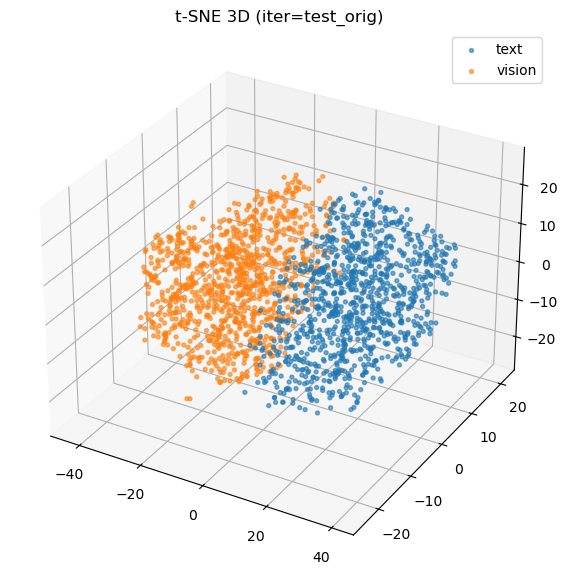

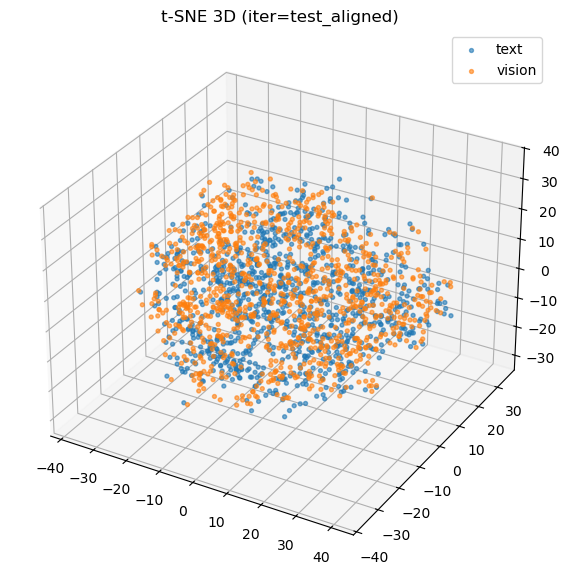

{'retrieval_orig': {1: 0.8745855331420899,
  5: 0.9741857385635376,
  10: 0.987749412059784},
 'retrieval_aligned': {1: 0.816645393371582,
  5: 0.9550916957855224,
  10: 0.9770928692817687},
 'gaps_orig': {'RMG': 0.7976485819287372,
  'L2M': 0.6844924092292786,
  'L2I': 1.163695216178894},
 'gaps_aligned': {'RMG': 0.6938672873763766,
  'L2M': 0.01859080232679844,
  'L2I': 1.0586942434310913}}

In [18]:
# Fit + evaluation (pre/post) con Procrustes ORTOGONALE
train_loader, test_loader = make_loaders(precomputed_dir, split_name="flickr30k", batch_size=256, seed=0, num_workers=0)

mapping_ortho_10k = fit_orthogonal_procrustes_on_10k(train_loader, n_fit=10_000, translate=True, scale=True, device="cpu")
test_stats_ortho = eval_test_pre_post(test_loader, mapping_ortho_10k, device="cpu")

test_stats_ortho

#### Note di lettura (cosa aspettarsi)

- Se l’ipotesi “isometria globale” tra le due modalità regge, l’**ortogonale** dovrebbe performare **quasi come** il Procrustes generico.
- Se invece il generico migliora molto di più, significa che parte del “gap” viene chiusa grazie a componenti **non isometriche** (scaling anisotropo / shear) che l’ortogonale non può usare.
- Con `translate=True, scale=True` stai già centrando e normalizzando Frobenius su train (come nel generic), quindi le differenze che rimangono sono principalmente dovute al **vincolo ortogonale su T**.


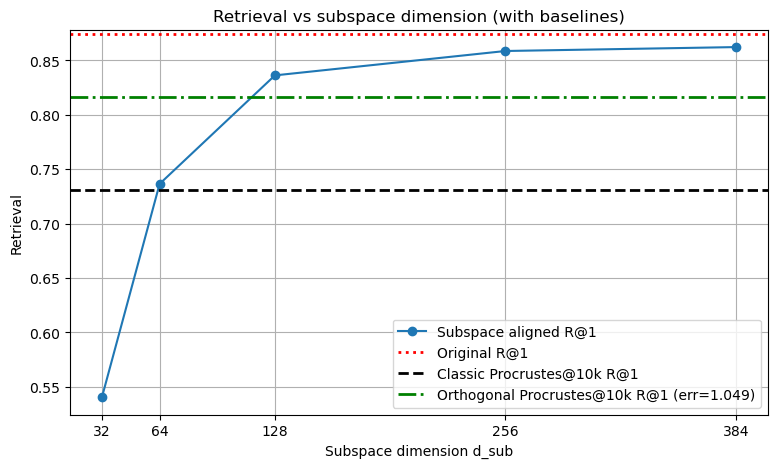

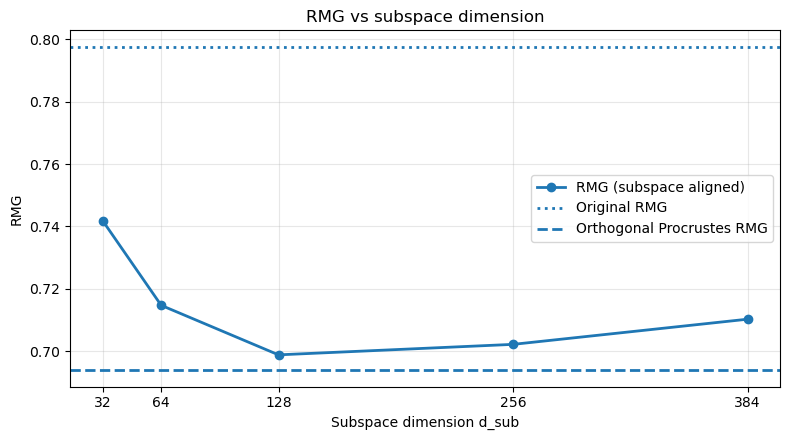

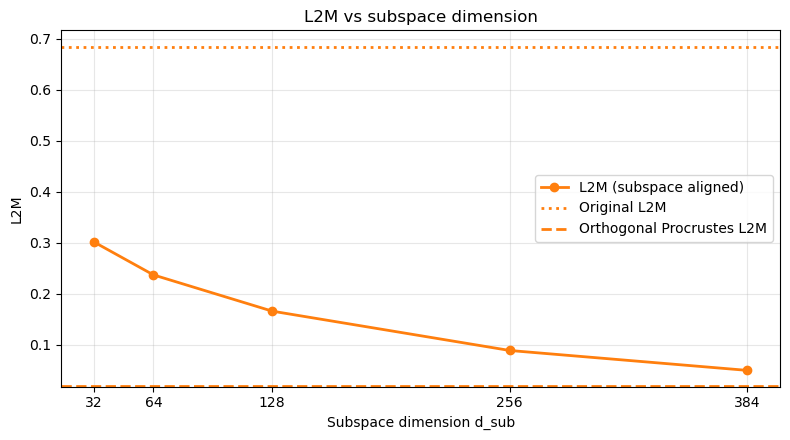

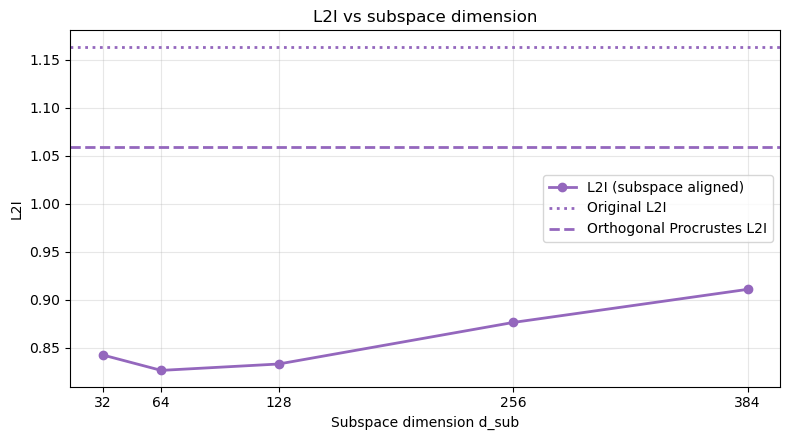

In [29]:
# --- Subspace sweep results (aligned) ---
results = [
    {"d_sub": 32,  "retrieval@1": 0.5406, "retrieval@5": 0.8407, "retrieval@10": 0.9180,
     "RMG": 0.7418968617387169, "L2M": 0.3014943301677704, "L2I": 0.8425172567367554},
    {"d_sub": 64,  "retrieval@1": 0.7365, "retrieval@5": 0.9356, "retrieval@10": 0.9671,
     "RMG": 0.7147150678988811, "L2M": 0.23713606595993042, "L2I": 0.8264103531837463},
    {"d_sub": 128, "retrieval@1": 0.8362, "retrieval@5": 0.9629, "retrieval@10": 0.9834,
     "RMG": 0.6988464308853876, "L2M": 0.16616225242614746, "L2I": 0.8330492377281189},
    {"d_sub": 256, "retrieval@1": 0.8586, "retrieval@5": 0.9715, "retrieval@10": 0.9849,
     "RMG": 0.7022089214672783, "L2M": 0.0890965685248375, "L2I": 0.8763177394866943},
    {"d_sub": 384, "retrieval@1": 0.8622, "retrieval@5": 0.9715, "retrieval@10": 0.9862,
     "RMG": 0.7102776515662346, "L2M": 0.05012039095163345, "L2I": 0.9108297228813171},
]

# --- Baselines ---
original_baseline = {
    "retrieval@1": 0.8746, "retrieval@5": 0.9742, "retrieval@10": 0.9877,
    "RMG": 0.7976485819287372, "L2M": 0.6844924092292786, "L2I": 1.163695216178894
}

classic_procrustes = {
    "retrieval@1": 0.7309, "retrieval@5": 0.9254, "retrieval@10": 0.9647,
    # (se non hai gap per classic, lasciali None oppure toglili)
    "RMG": None, "L2M": None, "L2I": None
}

orthogonal_procrustes = {
    "fit_error": 1.048972,
    "retrieval@1": 0.8166, "retrieval@5": 0.9551, "retrieval@10": 0.9771,
    "RMG": 0.6938672873763766, "L2M": 0.01859080232679844, "L2I": 1.0586942434310913
}

# ---- sort sweep by d_sub
results = sorted(results, key=lambda x: x["d_sub"])
d = np.array([r["d_sub"] for r in results])

# -----------------------------
# Plot 1: Retrieval@k vs d_sub
#   - original baseline in RED (dotted)
#   - classic procrustes baseline in BLACK (dashed)
#   - orthogonal procrustes baseline in GREEN (dashdot)
# -----------------------------
plt.figure(figsize=(9, 5))

# Sweep curves
plt.plot(d, [r["retrieval@1"] for r in results], marker='o', label="Subspace aligned R@1")
# plt.plot(d, [r["retrieval@5"] for r in results], marker='o', label="Subspace aligned R@5")
# plt.plot(d, [r["retrieval@10"] for r in results], marker='o', label="Subspace aligned R@10")

# Baselines
plt.axhline(original_baseline["retrieval@1"], color="red", linestyle=":", linewidth=2, label="Original R@1")
# plt.axhline(original_baseline["retrieval@5"], color="red", linestyle=":", linewidth=2, label="Original R@5")
# plt.axhline(original_baseline["retrieval@10"], color="red", linestyle=":", linewidth=2, label="Original R@10")

plt.axhline(classic_procrustes["retrieval@1"], color="black", linestyle="--", linewidth=2, label="Classic Procrustes@10k R@1")
# plt.axhline(classic_procrustes["retrieval@5"], color="black", linestyle="--", linewidth=2, label="Classic Procrustes@10k R@5")
# plt.axhline(classic_procrustes["retrieval@10"], color="black", linestyle="--", linewidth=2, label="Classic Procrustes@10k R@10")

plt.axhline(orthogonal_procrustes["retrieval@1"], color="green", linestyle="-.", linewidth=2,
            label=f"Orthogonal Procrustes@10k R@1 (err={orthogonal_procrustes['fit_error']:.3f})")
# plt.axhline(orthogonal_procrustes["retrieval@5"], color="green", linestyle="-.", linewidth=2,
#             label="Orthogonal Procrustes@10k R@5")
# plt.axhline(orthogonal_procrustes["retrieval@10"], color="green", linestyle="-.", linewidth=2,
#             label="Orthogonal Procrustes@10k R@10")

plt.xlabel("Subspace dimension d_sub")
plt.ylabel("Retrieval")
plt.title("Retrieval vs subspace dimension (with baselines)")
plt.xticks(d)
plt.grid(True)
plt.legend()
plt.show()


# -----------------------------
# Plot 2: One graph per gap metric
#   + baselines (original + orthogonal + classic if available)
# -----------------------------
for metric in ["RMG", "L2M", "L2I"]:
    plt.figure(figsize=(8, 4.5))

    # Subspace sweep
    plt.plot(
        d,
        [r[metric] for r in results],
        marker="o",
        linestyle="-",
        color=metric_colors.get(metric, "tab:blue"),
        linewidth=2,
        label=f"{metric} (subspace aligned)"
    )

    # Original baseline
    plt.axhline(
        original_baseline[metric],
        color=metric_colors.get(metric, "tab:blue"),
        linestyle=":",
        linewidth=2,
        label=f"Original {metric}"
    )

    # Orthogonal baseline
    plt.axhline(
        orthogonal_procrustes[metric],
        color=metric_colors.get(metric, "tab:blue"),
        linestyle="--",
        linewidth=2,
        label=f"Orthogonal Procrustes {metric}"
    )

    # Classic baseline (only if present)
    if classic_procrustes.get(metric) is not None:
        plt.axhline(
            classic_procrustes[metric],
            color=metric_colors.get(metric, "tab:blue"),
            linestyle="-.",
            linewidth=2,
            label=f"Classic Procrustes {metric}"
        )

    plt.xlabel("Subspace dimension d_sub")
    plt.ylabel(metric)
    plt.title(f"{metric} vs subspace dimension")
    plt.xticks(d)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [31]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.stats import spearmanr

def collect_embeddings_from_embedding_loader(loader, max_samples=20000, device="cpu"):
    """
    loader yields (text_emb, vision_emb) already computed.
    Returns X (text) and Y (vision) as numpy arrays [N,D], L2-normalized.
    """
    Xs, Ys = [], []
    seen = 0
    with torch.no_grad():
        for text_b, vis_b in tqdm(loader, desc=f"Collecting {max_samples} pairs"):
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b  = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()
            Xs.append(text_b)
            Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break
    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]
    return X, Y

def normalize01(v, eps=1e-12):
    v = v.astype(np.float64)
    return (v - v.min()) / (v.max() - v.min() + eps)

def analyze_gap_vs_subspace_importance(
    loader,
    sub_model,
    max_samples=20000,
    top_k=50,
    device="cpu"
):
    """
    sub_model must contain:
      - Ws: (D, d_sub) text basis
      - Wt: (D, d_sub) vision basis
      - d_sub: int
    """
    Ws = sub_model["Ws"]   # (D, d_sub)
    Wt = sub_model["Wt"]   # (D, d_sub)
    d_sub = sub_model.get("d_sub", Ws.shape[1])

    # 1) sample embeddings to compute per-dimension mean gap
    X, Y = collect_embeddings_from_embedding_loader(loader, max_samples=max_samples, device=device)
    D = X.shape[1]

    muX = X.mean(axis=0)  # (D,)
    muY = Y.mean(axis=0)  # (D,)

    gap_dim = np.abs(muX - muY)  # (D,) abs mean diff per dimension

    # 2) subspace importance per original dim
    imp_X = np.sum(Ws**2, axis=1)  # (D,)
    imp_Y = np.sum(Wt**2, axis=1)  # (D,)
    imp_joint = 0.5 * (imp_X + imp_Y)

    # 3) correlations (rank-based, robust)
    rho_x = spearmanr(gap_dim, imp_X).correlation
    rho_y = spearmanr(gap_dim, imp_Y).correlation
    rho_j = spearmanr(gap_dim, imp_joint).correlation

    # 4) top-k overlaps
    top_gap = np.argsort(-gap_dim)[:top_k]
    top_impX = np.argsort(-imp_X)[:top_k]
    top_impY = np.argsort(-imp_Y)[:top_k]
    top_impJ = np.argsort(-imp_joint)[:top_k]

    def overlap(a, b):
        return len(set(a).intersection(set(b)))

    ov_x = overlap(top_gap, top_impX)
    ov_y = overlap(top_gap, top_impY)
    ov_j = overlap(top_gap, top_impJ)

    print(f"\n=== Gap vs Subspace Importance (d_sub={d_sub}, N={X.shape[0]}, D={D}) ===")
    print(f"Spearman corr(gap_dim, imp_X)     = {rho_x:.4f}")
    print(f"Spearman corr(gap_dim, imp_Y)     = {rho_y:.4f}")
    print(f"Spearman corr(gap_dim, imp_joint) = {rho_j:.4f}")
    print(f"\nTop-{top_k} overlap:")
    print(f"  overlap(top gap, top imp_X) = {ov_x}/{top_k}")
    print(f"  overlap(top gap, top imp_Y) = {ov_y}/{top_k}")
    print(f"  overlap(top gap, top imp_J) = {ov_j}/{top_k}")

    # 5) plots (normalized to [0,1] so they are comparable)
    gap_n = normalize01(gap_dim)
    impX_n = normalize01(imp_X)
    impY_n = normalize01(imp_Y)
    impJ_n = normalize01(imp_joint)

    plt.figure(figsize=(10, 4))
    plt.plot(gap_n, label="gap per-dim |mean(text)-mean(vision)| (norm)")
    plt.plot(impJ_n, label="subspace importance joint (norm)")
    plt.title(f"Gap-per-dimension vs Subspace importance (d_sub={d_sub})")
    plt.xlabel("Original embedding dimension")
    plt.ylabel("Normalized value")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(6, 5))
    plt.scatter(gap_dim, imp_joint, s=8, alpha=0.5)
    plt.title(f"Scatter: gap_dim vs imp_joint (Spearman={rho_j:.3f})")
    plt.xlabel("gap_dim = |mean_x - mean_y|")
    plt.ylabel("imp_joint = 0.5(||Ws[j]||^2 + ||Wt[j]||^2)")
    plt.grid(True)
    plt.show()

    # 6) show top dims (useful for inspection)
    print("\nTop dims by GAP (abs mean diff):")
    for idx in top_gap[:min(20, top_k)]:
        print(f"  dim {idx:4d} | gap={gap_dim[idx]:.6f} | impJ={imp_joint[idx]:.6f}")

    print("\nTop dims by subspace importance (joint):")
    for idx in top_impJ[:min(20, top_k)]:
        print(f"  dim {idx:4d} | impJ={imp_joint[idx]:.6f} | gap={gap_dim[idx]:.6f}")

    return {
        "gap_dim": gap_dim,
        "imp_X": imp_X,
        "imp_Y": imp_Y,
        "imp_joint": imp_joint,
        "rho": {"gap_impX": rho_x, "gap_impY": rho_y, "gap_impJ": rho_j},
        "top": {"gap": top_gap, "impX": top_impX, "impY": top_impY, "impJ": top_impJ},
        "overlap": {"gap_impX": ov_x, "gap_impY": ov_y, "gap_impJ": ov_j},
    }


=== Gap vs Subspace Importance (d_sub=256, N=20000, D=512) ===
Spearman corr(gap_dim, imp_X)     = 0.1874
Spearman corr(gap_dim, imp_Y)     = 0.2481
Spearman corr(gap_dim, imp_joint) = 0.2402

Top-50 overlap:
  overlap(top gap, top imp_X) = 15/50
  overlap(top gap, top imp_Y) = 17/50
  overlap(top gap, top imp_J) = 13/50


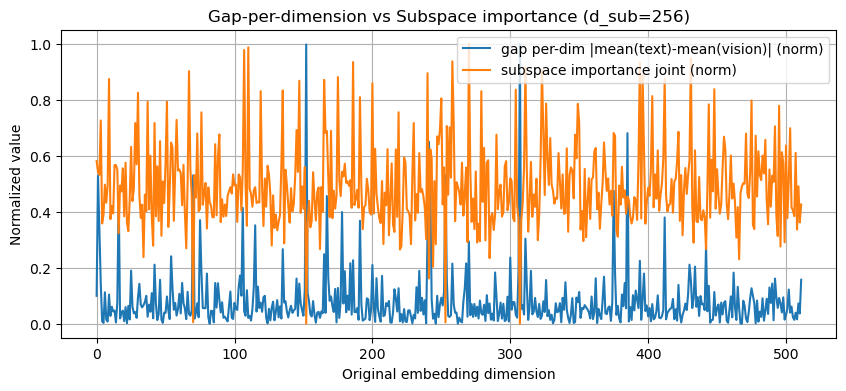

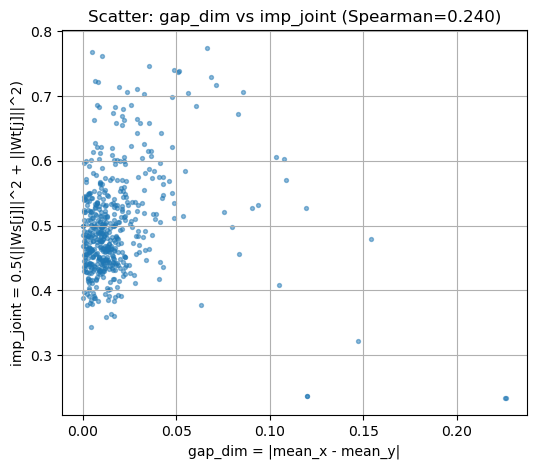


Top dims by GAP (abs mean diff):
  dim  307 | gap=0.226368 | impJ=0.234531
  dim  152 | gap=0.225757 | impJ=0.234543
  dim  385 | gap=0.154046 | impJ=0.480071
  dim  241 | gap=0.147177 | impJ=0.321785
  dim   70 | gap=0.120005 | impJ=0.237337
  dim  253 | gap=0.119960 | impJ=0.237170
  dim    1 | gap=0.119526 | impJ=0.527354
  dim  242 | gap=0.108904 | impJ=0.570750
  dim  375 | gap=0.107530 | impJ=0.602300
  dim   16 | gap=0.105013 | impJ=0.408979
  dim  167 | gap=0.103209 | impJ=0.606029
  dim  106 | gap=0.093668 | impJ=0.531960
  dim  178 | gap=0.090284 | impJ=0.527584
  dim  412 | gap=0.085932 | impJ=0.705823
  dim   75 | gap=0.083721 | impJ=0.456421
  dim  191 | gap=0.083236 | impJ=0.671435
  dim  115 | gap=0.079584 | impJ=0.497735
  dim    2 | gap=0.075396 | impJ=0.521527
  dim  240 | gap=0.071251 | impJ=0.717515
  dim  311 | gap=0.068759 | impJ=0.729779

Top dims by subspace importance (joint):
  dim  270 | impJ=0.774425 | gap=0.066504
  dim  110 | impJ=0.767455 | gap=0.004744


In [32]:
analysis = analyze_gap_vs_subspace_importance(
    loader=train_loader,     # oppure un loader dedicato per stimare mean gap (train meglio)
    sub_model=sub_model,     # quello fit con d_sub=256
    max_samples=20000,       # aumenta a 50k se vuoi stime più stabili
    top_k=50,
    device="cpu"
)

possiamo provare a fattorizzare uno spazio latente multimodale a d dimensioni dove per ogni diemnsione valutiamo:
- come agisce sul gap
- quanto è utile per la semantica

Selezionare n dimensioni con gap alto e rimuoverle e runnare retrieval 
Stessa cosa per le dimensioni cons emantica alta